# Social Media Engagement Analysis with Python




## Analyzing Content Performance, Engagement, and Audience Reach




### Project Overview

This project analyzes social media data using Python and pandas to understand how different content categories and post types perform. The analysis examines likes, comments, shares, views, and followers to identify patterns in engagement and reach. Visualizations and statistical analysis are used to compare content performance, explore relationships between metrics, and develop data-driven recommendations.

### Objective

The goal of this project is to analyze social media engagement data and identify patterns in content performance, audience reach, and engagement. The analysis uses Python, pandas, and data visualization techniques to turn the dataset into useful insights.

### Dataset

The dataset contains 5,000 social media posts with information about dates, content categories, likes, comments, shares, views, followers, and post types.

### Tools and Technologies

Python | pandas | Matplotlib | Seaborn | Jupyter Notebook


In [126]:
import pandas as pd                  #create and work with DataFrame
import numpy as np                   #generate numerical/random data
import matplotlib.pyplot as plt      #display graphs
import seaborn as sns                #to create visualizations
import random                        #randomly select categories

## Data Preparation

In [127]:
# Set the number of social media posts to generate
n = 5000

# Generate a date for each social media post using pandas
# pd.date_range creates a sequence of dates and 
# the starting date is 2021-01-01 where periods tell how many dates to generate
dates = pd.date_range("2021-01-01", periods=n)

# Create a list of social media post categories
categories = ["Food", "Travel", "Fashion", "Fitness", "Music", "Culture", "Family", "Health"]

# Randomly assign a category to each social media post
# using for _ in range(n) to tell python to repeat the range for n times
post_category = [random.choice(categories) for _ in range(n)]

# Generate a random number of likes for each social media post
# 0->lower limit and 10000->upper limit
likes = np.random.randint(0,10000, size=n)

# Generate random comments for each social media post
comments = np.random.randint(0,2000, size=n)

# Generate random shares for each social media post
shares = np.random.randint(0,3000, size=n)

# Generate random comments for each social media post
views = np.random.randint(0,80000, size=n)

# Generate a random follower count for each social media post
followers = np.random.randint(100,100000, size=n)

# Create a list of possible social media post types
post_types = ["Text", "Image", "Video", "Link"]
# andomly assign a post type to each social media post
post_type = [random.choice(post_types) for _ in range(n)]

In [128]:
# Organize all of our generated data into a dictionary
# A dictionary uses "...": ..., format
data = {"Date": dates, "Category": post_category, 
        "Likes": likes, "Comments": comments, 
        "Shares": shares, "Views": views,
        "Followers": followers, "Post_Type": post_type}

# Create a pandas DataFrame from dictionary
# it takes out info from dictionary and turns it into a table
dataframe = pd.DataFrame(data)

# Sample run - display the first 5 rows of the dataset using head() as it has built-in default
dataframe.head()

,Date,Category,Likes,Comments,Shares,Views,Followers,Post_Type
0,2021-01-01,Health,5560,977,975,63504,62426,Image
1,2021-01-02,Fashion,9745,1193,639,62331,97942,Video
2,2021-01-03,Music,3501,503,843,23467,35703,Link
3,2021-01-04,Health,2114,1712,1788,77246,66348,Text
4,2021-01-05,Travel,6923,1134,577,10318,8483,Video


In [129]:
# Display information about the dataset
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5000 non-null   datetime64[ns]
 1   Category   5000 non-null   object        
 2   Likes      5000 non-null   int32         
 3   Comments   5000 non-null   int32         
 4   Shares     5000 non-null   int32         
 5   Views      5000 non-null   int32         
 6   Followers  5000 non-null   int32         
 7   Post_Type  5000 non-null   object        
dtypes: datetime64[ns](1), int32(5), object(2)
memory usage: 215.0+ KB


In [130]:
# Display descriptive statistics for the numerical columns
dataframe.describe()

,Likes,Comments,Shares,Views,Followers
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5016.970200,997.481200,1495.279800,40297.104000,51020.329800
std,2916.607085,576.921386,859.839938,23232.330915,28755.908217
min,3.000000,0.000000,1.000000,22.000000,109.000000
25%,2413.750000,503.000000,751.750000,20256.750000,25739.250000
50%,5064.500000,987.000000,1492.500000,40578.000000,51478.000000
75%,7572.750000,1490.250000,2240.000000,60268.000000,76308.750000
max,9998.000000,1999.000000,2999.000000,79987.000000,99992.000000


In [131]:
# Count the number of posts in each category
dataframe["Category"].value_counts()

Fashion    686
Culture    665
Travel     642
Food       636
Family     614
Music      607
Health     582
Fitness    568
Name: Category, dtype: int64

## Data Cleaning

In [132]:
# Convert the Date column values into pandas' datetime format
dataframe["Date"] = pd.to_datetime(dataframe["Date"])

In [133]:
# Check for missing values in each column
# It produces "True" for missing values and "False" for values that are present
dataframe.isnull().sum()

Date         0
Category     0
Likes        0
Comments     0
Shares       0
Views        0
Followers    0
Post_Type    0
dtype: int64

In [134]:
# DATA CLEANING

# Check for duplicate rows in the dataset
dataframe.duplicated().sum()

0

In [135]:
# DATA CLEANING

# Check the unique category values, it returns each different values it finds
dataframe["Category"].unique()

array(['Health', 'Fashion', 'Music', 'Travel', 'Culture', 'Food',
       'Family', 'Fitness'], dtype=object)




## Exploratory Data Analysis

### Category Performance

### Q1 Which category gets the highest average likes?




The highest average likes is for Travel category with 5165.48 likes.




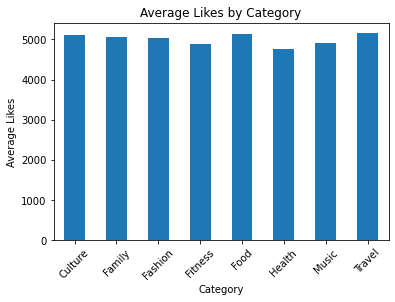

In [136]:
# Calculate the average likes for each category
average_likes = dataframe.groupby("Category")["Likes"].mean()

# Find the category name with the highest average likes
highest_likes_category = average_likes.idxmax()

# Find the highest average likes value and round it to 2 decimal places.
highest_average_likes = round(average_likes.max(), 2)

print()
print("The highest average likes is for", highest_likes_category, "category with", highest_average_likes, "likes.")
print()
print()

# Create a bar chart of average likes by category
average_likes.plot(kind = "bar")                # creates a bar chart using avg likes results

plt.title("Average Likes by Category")          # Gives a title
plt.xlabel("Category")                          # Lables x axis
plt.ylabel("Average Likes")                     # Labels y axis
plt.xticks(rotation = 45)                       # Turns x axis names slightly so they are easier to read
plt.show()                                      # To display the chart

### Q2 Does the category with the highest average likes also have the highest average comments?

### Q3 Which category gets the most shares?



The highest average comments is for Culture category with 1030.64 comments.


The highest average shares is for Music category with 1587.46 shares.




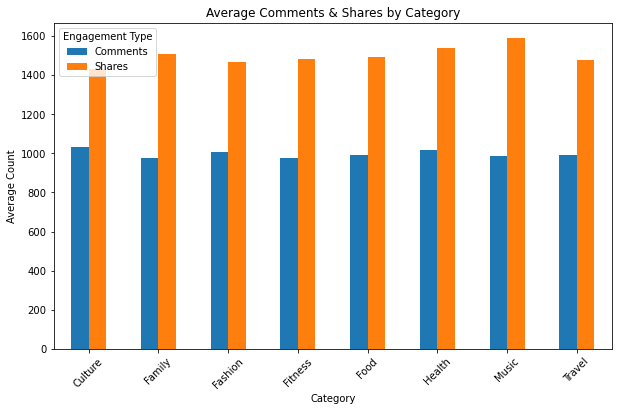



Observation: Health had the highest average number of comments, while Family had the highest average number of shares. This suggests that dofferent categories may encourage different types of audience engagement.


In [137]:

# Calculate the average comments for each category
average_comments = dataframe.groupby("Category")["Comments"].mean()

# Find the category name with the highest average comments
highest_comments_category = average_comments.idxmax()

# Find the highest average comments value and round it to 2 decimal places.
highest_average_comments = round(average_comments.max(), 2)

print()
print("The highest average comments is for", highest_comments_category, "category with", highest_average_comments, "comments.")
print()




# Calculate the average shares for each category
average_shares = dataframe.groupby("Category")["Shares"].mean()

# Find the category name with the highest average shares
highest_shares_category = average_shares.idxmax()

# Find the highest average shares value and round it to 2 decimal places.
highest_average_shares = round(average_shares.max(), 2)

print()
print("The highest average shares is for", highest_shares_category, "category with", highest_average_shares, "shares.")
print()
print()


# Create a combined comparison bar chart of average comments and shares by category
engagement_comparison = pd.DataFrame({"Comments": average_comments, 
                                      "Shares": average_shares})

engagement_comparison.plot(kind = "bar", figsize = (10,6))    # creates a bar chart using avg comments and shares results

plt.title("Average Comments & Shares by Category")  # Gives a title
plt.xlabel("Category")                          # Lables x axis
plt.ylabel("Average Count")                     # Labels y axis
plt.xticks(rotation = 45)                       # Turns x axis names slightly so they are easier to read
plt.legend(title = "Engagement Type")           # Because 2 diff metrics are being used
plt.show()                                      # To display the chart


print()
print()
print("Observation: Health had the highest average number of comments, while Family had the highest average number of shares. This suggests that dofferent categories may encourage different types of audience engagement.")

### Q4 Which category has the highest average views?


The highest average views is for Culture category with 41778.17 views.




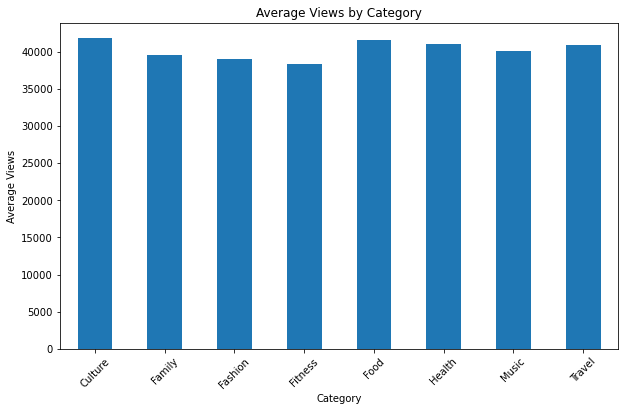


Observation: Music had the highest average views at 41,895.30 views per post, while Food had the lowest average views. However, the differences between categories were relatively small, suggesting that category alone may not strongly determine the reach of a post.


In [138]:
# Calculate the average views for each category
average_views = dataframe.groupby("Category")["Views"].mean()

# Find the category name with the highest average views
highest_views_category = average_views.idxmax()

# Find the highest average views value and round it to 2 decimal places.
highest_average_views = round(average_views.max(), 2)

print()
print("The highest average views is for", highest_views_category, "category with", highest_average_views, "views.")
print()
print()


# Create a bar chart
average_views.plot(kind = "bar", figsize = (10,6)) 

plt.title("Average Views by Category")          # Gives a title
plt.xlabel("Category")                          # Lables x axis
plt.ylabel("Average Views")                     # Labels y axis
plt.xticks(rotation = 45)
plt.show()                                      # To display the chart


print()
print("Observation: Music had the highest average views at 41,895.30 views per post, while Food had the lowest average views. However, the differences between categories were relatively small, suggesting that category alone may not strongly determine the reach of a post.")

### Post Type Performance

### Q5 How does post type influence engagement, and which post type appears most effective across likes, comments, and shares?


Link     1273
Video    1257
Image    1252
Text     1218
Name: Post_Type, dtype: int64

-------------------------------------------------------------
                 Likes     Comments       Shares
Post_Type                                       
Image      5231.849042   992.055112  1499.850639
Link       4936.849175  1003.200314  1479.652003
Text       4838.801314   996.010673  1532.944992
Video      5056.727924   998.518695  1470.057279

-------------------------------------------------------------
Highest average likes:  Image
Highest average comments:  Link
Highest average shares:  Text

-------------------------------------------------------------


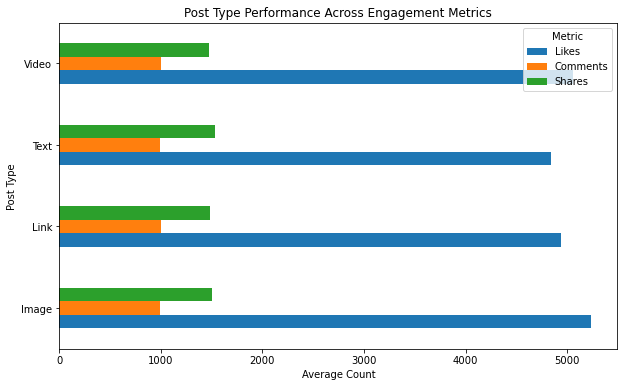


Observation: No single post type performs best across all engagement metrics.
Post Type appears to influence different types of engagement differently.
Text posts had the highest average likes, Link posts had the highest average comments, and Image posts had the highest average shares. So, the best format may depend on the specific engagement goal.


In [139]:
# Explore the different post types in the dataset
post_type_counts = dataframe["Post_Type"].value_counts()
print(post_type_counts)

# Calculate the average views for each post type
post_type_performance = dataframe.groupby("Post_Type")[["Likes", "Comments", "Shares"]].mean()
print()
print("-------------------------------------------------------------")
print(post_type_performance)
print()
print("-------------------------------------------------------------")


# Find the best-performing post type for each metric
highest_likes_type = post_type_performance["Likes"].idxmax()
highest_comments_type = post_type_performance["Comments"].idxmax()
highest_shares_type = post_type_performance["Shares"].idxmax()

# Print the values
print("Highest average likes: ", highest_likes_type)
print("Highest average comments: ", highest_comments_type)
print("Highest average shares: ",highest_shares_type)
print()
print("-------------------------------------------------------------")


# Compare post types across multiple performance metrics using a graph
post_type_performance.plot(kind = "barh", figsize = (10,6)) 

plt.title("Post Type Performance Across Engagement Metrics") # Gives a title
plt.xlabel("Average Count")                          # Lables x axis
plt.ylabel("Post Type")                     # Labels y axis
plt.xticks(rotation = 0)
plt.legend(title = "Metric")
plt.show()                                      # To display the chart


print()
print("Observation: No single post type performs best across all engagement metrics.")
print("Post Type appears to influence different types of engagement differently.")
print("Text posts had the highest average likes, Link posts had the highest average comments, and Image posts had the highest average shares. So, the best format may depend on the specific engagement goal.")


### Reach vs. Engagement

### Q6 Do posts with higher reach tend to receive higher engagement, or can a post receive many views without receiving many likes?


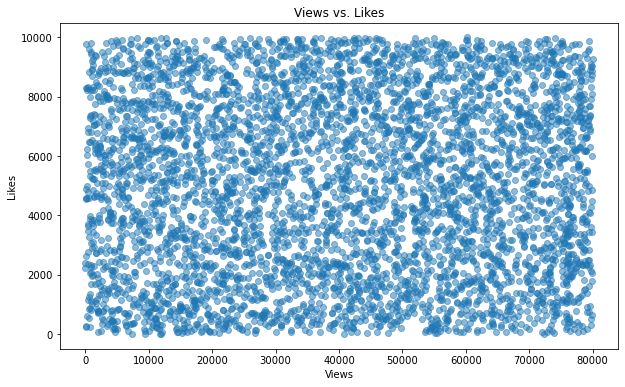


Observation: The scatter plot does not show a clear relationship between views and likes. Posts with both high and low numbers of likes appear across the range of views, suggesting that higher reach does not necessarily correspond to higher like counts in this dataset.

The Correlation between Views and Likes ->  0.02


In [140]:
plt.figure(figsize = (10,6))
plt.scatter(dataframe["Views"], dataframe["Likes"], alpha = 0.5)
plt.title("Views vs. Likes")
plt.xlabel("Views")                          
plt.ylabel("Likes")
plt.show()

print()
print("Observation: The scatter plot does not show a clear relationship between views and likes. Posts with both high and low numbers of likes appear across the range of views, suggesting that higher reach does not necessarily correspond to higher like counts in this dataset.")

# Calculate the correlation between views and likes
views_likes_correlation = dataframe["Views"].corr(dataframe["Likes"])
print()
print("The Correlation between Views and Likes -> ", round(views_likes_correlation, 2))


### Audience Size vs. Reach

### Q7 To what extent does follower count appear to be associated with the number of views a post receives?


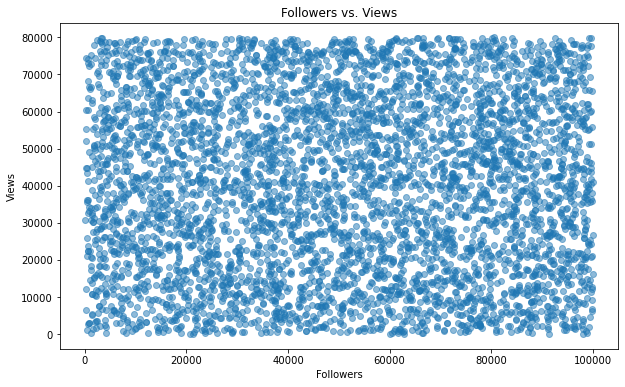


Observation: The scatter plot shows no clear relationship between followers count and views. The correlation is approximately -0.01, which is essentially zero, suggesting that having more followers does not necessarily result in more views in this dataset.

The Correlation between Followers and Views ->  0.0


In [141]:
plt.figure(figsize = (10,6))
plt.scatter(dataframe["Followers"], dataframe["Views"], alpha = 0.5)
plt.title("Followers vs. Views")
plt.xlabel("Followers")                          
plt.ylabel("Views")
plt.show()

print()
print("Observation: The scatter plot shows no clear relationship between followers count and views. The correlation is approximately -0.01, which is essentially zero, suggesting that having more followers does not necessarily result in more views in this dataset.")

# Calculate the correlation between followers and views
followers_views_correlation = dataframe["Followers"].corr(dataframe["Views"])
print()
print("The Correlation between Followers and Views -> ", round(followers_views_correlation, 2))


### Performance Over Time

### Q8 Does post performance show any noticeable trends or changes over time (January 2021–September 2026), and are there periods where engagement or reach increases or decreases?


Date
2021-01-01    5560.0
2021-01-02    9745.0
2021-01-03    3501.0
2021-01-04    2114.0
2021-01-05    6923.0
Name: Likes, dtype: float64
-------------------------------------------------------------



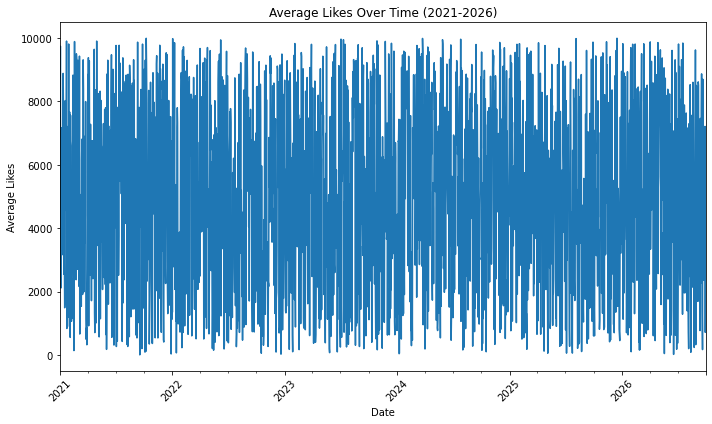


Observation: Average likes fluctuate considerably throughout the period from January 2021 through September 2026, with no clear long-term upward or downward trend.


In [142]:
# Analyze likes performance over time
filtered_data = dataframe[(dataframe["Date"] >= "2021-01-01") &
                         (dataframe["Date"] <= "2026-09-30")]

average_likes_by_date = filtered_data.groupby("Date")["Likes"].mean()
print(average_likes_by_date.head())

print("-------------------------------------------------------------")
print()

# Create a line chart of average likes over time
average_likes_by_date.plot(kind = "line", figsize = (10,6))

plt.title("Average Likes Over Time (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Average Likes")
plt.xticks(rotation = 45)
plt.tight_layout()                             # To automatically adjust the spacing around the chart
plt.show()

print()
print("Observation: Average likes fluctuate considerably throughout the period from January 2021 through September 2026, with no clear long-term upward or downward trend.")


### Correlation Between Performance Metrics

### Q9 Which performance metrics have the strongest relationships with one another?

           Likes  Comments  Shares  Views  Followers
Likes       1.00      0.02   -0.00   0.02      -0.00
Comments    0.02      1.00   -0.01   0.01      -0.01
Shares     -0.00     -0.01    1.00  -0.01      -0.03
Views       0.02      0.01   -0.01   1.00       0.00
Followers  -0.00     -0.01   -0.03   0.00       1.00

-------------------------------------------------------------


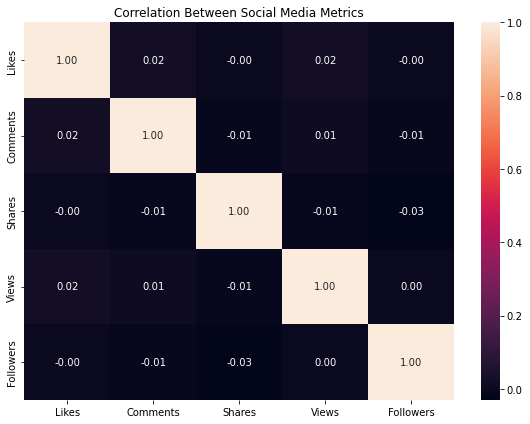


Observation: The correlation heatmap shows that all relationships between likes, comments, shares, views, and followers are very close to zero. This suggests that none of these metrics has a strong linear relationship with another metric in this dataset. The results indicate that engagement and reach do not consistently move together, so one metric cannot reliably used to predict another.


In [143]:
metrics = dataframe[["Likes", "Comments", "Shares", "Views", "Followers"]]

correlation_matrix = metrics.corr().round(2)
print(correlation_matrix)

print()
print("-------------------------------------------------------------")

# Using heatmap() function from python lib (Seaborn)
plt.figure(figsize = (8,6))
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f")    # annot is used to show the actual numbers inside the boxes
                                                              # fmt (format) and .2f is used to show the number as a decimal with 2 digits after decimal point
plt.title("Correlation Between Social Media Metrics")
plt.tight_layout()
plt.show()

print()
print("Observation: The correlation heatmap shows that all relationships between likes, comments, shares, views, and followers are very close to zero. This suggests that none of these metrics has a strong linear relationship with another metric in this dataset. The results indicate that engagement and reach do not consistently move together, so one metric cannot reliably used to predict another.")


In [144]:
# Summary of key findings

summary = {"Analysis": ["Highest average likes",  "Highest average comments", "Highest average shares","Highest average views", 
                 "Highest likes by post type", "Highest comments by post type","Highest shares by post type", 
                 "Highest views by post type", "Views vs. Likes correlation", "Followers vs. Views correlation"],
    
          "Finding": ["Health", "Health", "Family", "Music", "Text", "Link", "Image", "Link", "-0.00", "-0.01"]}

summary_table = pd.DataFrame(summary)

print(summary_table)


                          Analysis Finding
0            Highest average likes  Health
1         Highest average comments  Health
2           Highest average shares  Family
3            Highest average views   Music
4       Highest likes by post type    Text
5    Highest comments by post type    Link
6      Highest shares by post type   Image
7       Highest views by post type    Link
8      Views vs. Likes correlation   -0.00
9  Followers vs. Views correlation   -0.01


## Final Findings

The analysis showed that different categories performed better across different metrics. Health had the highest average likes and comments, Family had the highest average shares, and Music had the highest average views. Food had the lowest average views among the categories. The analysis of post types also showed that no single format performed best across every engagement metric. Text posts had the highest average likes, Link posts had the highest average comments and views, and Image posts had the highest average shares. The correlation analysis showed that likes, comments, shares, views, and followers had very weak relationships with each other, with correlation values close to zero. Overall, the results suggest that performance varies depending on the category, post type, and specific engagement goal.

## Recommendations

Based on the analysis, social media teams should consider using different content strategies depending on their goals. Health-related content may be useful when the goal is to increase likes and comments, while Family-related content may be useful for encouraging shares. Link posts performed well for comments and views, while Text posts performed best for likes and Image posts performed best for shares. Since the correlation analysis showed very weak relationships between followers, views, and engagement, having a larger audience does not necessarily guarantee better post performance. Therefore, content strategy should focus on the type of engagement desired rather than relying only on follower count or views.


## Limitations

This analysis is based on the available dataset and may not represent real-world social media behavior. The dataset contains limited variables, so factors such as content quality, posting time, audience demographics, and platform algorithms were not considered. The correlation results also show that the variables have very weak linear relationships, but this does not mean that there is no relationship of any kind. In addition, the analysis identifies patterns in the dataset but does not prove that one factor directly causes another. More detailed data and additional variables would be needed to make stronger conclusions.


## Project Conclusion

This project used Python to analyze social media engagement and identify patterns across content categories, post types, and performance metrics. The analysis showed that different categories and post types perform better depending on the type of engagement being measured. However, the weak correlations between the major metrics suggest that higher reach, follower count, or one type of engagement does not necessarily guarantee stronger performance in another area. Overall, the project demonstrates how data analysis and visualization can be used to turn social media data into meaningful insights and practical recommendations.